# non-NBRA calculations with OpenMolcas/Libra

In this tutorial, we will first demonstrate how the existing infrastructure/functions for OpenMolcas can be used to generate the files for a non-NBRA workflow with OpenMolcas/Libra will be demonstrated.

## Table of contents
<a name="toc"></a>
1. [Non-NBRA calculations](#1)

   1.1. [Molecule](#1.1)

   1.2. [Wigner sampling](#1.2)
   
   1.3. [Initial conditions - nuclear and electronic](#1.3)
   
   1.4. [Dynamical parameters](#1.4)
   
   1.5. [Model parameters](#1.5)
   
   1.6. [Run calculations](#1.6)

   1.7. [Let's visualize some properties](#1.7)
   
   1.8. [Make trajectories for VMD visualization of dynamics](#1.8)
   

### A. Learning objectives

* To execute non-NBRA workflow with OpenMolcas


### B. Use cases

* process the OpenMolcas calculations results
* compute wavefunction time-overlaps with OpenMolcas
* non-NBRA workflow with OpenMolcas


### C. Functions

- `libra_py`
  - `packages`
    - `openmolcas`
      - `methods`
        - [`molcas_compute_adi`](#molcas_compute_adi-1) | [`also here`](#molcas_compute_adi-2)


In [1]:
import os
import sys
import numpy as np
import h5py
from liblibra_core import MATRIX, CMATRIX, CMATRIXList, Py2Cpp_int, Cpp2Py, Random
from libra_py import units
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.packages.openmolcas.methods as openmolcas
from libra_py.wigner import generate_wigner_from_hessian
from recipes import fssh2
from libra_py.read_hessian import read_openmolcas
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot

%matplotlib inline

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. Non-NBRA calculations
<a name="2"></a>[Back to TOC](#toc)

The calculations are organized into several blocks:

1. Specification of the molecule and key variables 
2. Nuclear and electronic initial conditions
3. Defining dynamical parameters
4. Setting up the model (OpenMolcas) parameters
5. Running calculations
6. Plotting the results

### 1.1. Molecule
<a name="1.1"></a>[Back to TOC](#toc)

For a molecule of `N` atoms, we need:

- `labels`: chemical symbols of all atoms in the molecule (length of N)
- `coords`: coordinates of all atoms (as a 1D list with 3N elements, units: Angstrom)
- `nexcitations`: how many excited states to consider, the total number of states - `nstates` - is 1 larger than this number
- `ntraj`: how many trajectories we are going to run
- `mass_dict`: make sure to define the masses (in amu, hydrogen atom 1 amu) of all chemical species in your system
- `temperature`: temperature neede for wigner sampling

In [2]:
def do_al3():
    labels = ['Al', 'Al', 'Al']
    coords = [
        -1.03293,  1.44509,  0.00000,
        -2.10052, -0.80222,  0.00000,
         0.37950, -0.60313,  0.00000
    ]
    ndof = len(coords)
    q    = [x * units.Angst for x in coords]
    p    = [0.0 for _ in range(ndof)]

    mass      = []
    mass_dict = {"Al": 26.982}
    for elt in labels:
        m = mass_dict[elt] * units.amu
        mass.extend([m, m, m])

    print(f"ndof = {ndof}")
    nat = len(labels)
    print(f"nat  = {nat}")

    nexcitations = 7
    nstates      = nexcitations + 1
    return labels, q, p, mass, nat, nexcitations, nstates, ndof

In [3]:

labels, q, p, mass, nat, nexcitations, nstates, ndof = do_al3()

ntraj       = 1
DT          = 0.5    # fs
ISTATE      = 2
temperature = 300.0
traj_idx    = 0

ndof = 9
nat  = 3


### 1.2. Wigner sampling
<a name="1.2"></a>[Back to TOC](#toc)

Here we generates the initial conditions (positions & momenta) using the Wigner distribution — a quasi-probability distribution that captures quantum zero-point energy effects, unlike classical Boltzmann sampling.

- `hessian_matrix`: A variable storing the result returned by function read_openmolcas("hessian.slapaf.h5") Libra utility that reads output files from OpenMolcas calculations written in .slapaf.h5 file
- `res_wigner`: A variable that stores whatever value is returned by the function generate_wigner_from_hessian()

- `q_eq`: np.array(q, dtype=float) The equilibrium geometry — a 1D flattened array of atomic Cartesian coordinates [x1, y1, z1, x2, y2, z2 .... ] in atomic units (Bohr). This is the center of the Wigner distribution. All sampled geometries are displacements around this minimum-energy structure. Shape (3N,) where N = number of atoms

- `hessian`: hessian matrix, it is 3N×3N matrix of second derivatives of the potential energy. Used to construct the mass-weighted Hessian, which is then diagonalized to obtain normal mode frequencies ωk and eigenvectors. These define the shape and width of the Wigner distribution in each mode.

- `masses`: np.array(mass, dtype=float) Array of atomic masses, one per atom (length N), typically in atomic mass units (amu) Mass-weighting is essential — heavier atoms move less for the same force. The mass-weighted Hessian H~ij = Hij/(mimj)^-1/2 gives physically correct normal modes

- `temperature`: Temperature (in Kelvin) used to thermally populate the Wigner distribution
At T=0 K, only zero-point energy (ZPE) contributes to the width of the distribution (purely quantum). At higher T, thermal energy broadens the distribution further as

Wigner formula  σ^2q = ℏ/2ωk(coth(ℏωk/2kBT)

- `ntraj`: Set to 1 because the script is generating one sample per call (inside a loop over traj_idx)

- `seed`: Seed = 42 + traj_idx, Each trajectory gets a unique but reproducible seed, ensuring:

✅ Different trajectories get different random samples

✅ The entire ensemble is fully reproducible if you re-run the script

- `amu_to_au`: 1.0 This means the masses passed in masses are already in atomic units

- `zero_threshold`: 1.0e-6 A small numerical cutoff for treating a normal mode frequency as effectively zero. The 6 (or 5 for linear) translational and rotational modes have frequencies near zero. Any mode with ∣ωk∣< zero_threshold is excluded from sampling — otherwise division by ωk≈0 would cause infinite displacements. 

- `imaginary_threshold`: 1.0e-6  A cutoff for identifying imaginary frequencies. Imaginary frequencies indicate the geometry is a transition state or a saddle point, not a true minimum. Modes with ωk^2 < -imaginary_threshold are flagged or skipped, preventing unphysical sampling along unstable directions.


In [4]:
hessian_matrix = read_openmolcas("hessian.slapaf.h5")


res_wigner = generate_wigner_from_hessian(
    q_eq=np.array(q, dtype=float),
    hessian=hessian_matrix,
    masses=np.array(mass, dtype=float),
    temperature=temperature,
    ntraj=1,
    seed=42 + traj_idx,
    amu_to_au=1.0,
    zero_threshold=1.0e-6,       
    imaginary_threshold=1.0e-6    
)

It writes the vibrational frequencies calculated from the Hessian matrix, converting them to spectroscopic units and classifying the modes.
The array of normal mode eigenvalues ωk (in atomic units) Iterates through frequencies, providing both index i and value w The normal mode index (0-based Python indexing) The angular frequency ωk of the k-th normal mode in atomic units

Frequency Conversion
- `freq_cm`: w * 219474.63067 Conversion factor from atomic units of frequency (Hartree/ħ) to wavenumbers (cm⁻¹)

Mode Classification
- `w`: > 1.0e-5 Vibrational mode — has non-zero frequency, corresponds to actual chemical vibrations
else Translational/Rotational mode — frequency below threshold, corresponds to rigid-body motions
The 6 translational/rotational modes have theoretically zero frequency

It prints Mode number and corresponding frequency in cm⁻¹ unit with mode type [vib] [zero(trans/rot)]

- `ic`: res_wigner["ics"][0] generates the array of initial conditions [positions_array, momenta_array]

- `mass`: res_wigner["mass_cart_au"].tolist() Atomic masses in Cartesian form and converts from NumPy array to Python list

shape: (3N,) — each Cartesian degree of freedom gets its corresponding atomic mass
Needed for:
• Verifying total energy (KE + PE)
• Dynamics propagation
• Unit conversions in analysis
• Wigner sampling


In [5]:
print("\nNormal-mode frequencies:")
for i, w in enumerate(res_wigner["omega_au"]):
    freq_cm = w * 219474.63067
    kind    = "vib" if w > 1.0e-5 else "zero (trans/rot)"
    print(f"  Mode {i+1:2d}: {freq_cm:10.3f} cm^-1  [{kind}]")

ic   = res_wigner["ics"][0]
mass = res_wigner["mass_cart_au"].tolist()


Normal-mode frequencies:
  Mode  1:      0.000 cm^-1  [zero (trans/rot)]
  Mode  2:      0.000 cm^-1  [zero (trans/rot)]
  Mode  3:      0.000 cm^-1  [zero (trans/rot)]
  Mode  4:      0.000 cm^-1  [zero (trans/rot)]
  Mode  5:      0.000 cm^-1  [zero (trans/rot)]
  Mode  6:      0.000 cm^-1  [zero (trans/rot)]
  Mode  7:    246.163 cm^-1  [vib]
  Mode  8:    362.886 cm^-1  [vib]
  Mode  9:    380.156 cm^-1  [vib]


### 1.3. Initial conditions - nuclear and electronic
<a name="1.3"></a>[Back to TOC](#toc)

**Nuclear parameters**
- `ndof`: the number of degrees of freedom (3N) - defined above
- `q`: Wigner sampled positions of coordinates (Bohr) - defined above
- `p`: Wigner sampled momenta - defined above
- `mass`: masses of all DOFs - defined above
- `init_type = 4`: defined q and p spread manually
- `q_width` and `p_width`: set up some reasonable values

--- 

**Electronic parameters**

- `istate = 2`: initial electronic state
- `rep = 1`: initial states are chosen as adiabatic
- `init_type = 1` : initialize random phases of non-zero electronic amplitudes

In [6]:
############################################################
### 1. Choose the initial conditions: Nuclear and Electronic
############################################################

# Nuclear initial conditions 
nucl_params = {
                "ndof"          : ndof,
                "q"             : ic["q"].tolist(),
                "p"             : ic["p"].tolist(),
                "mass"          : mass,
                "force_constant": [0.0 for _ in range(ndof)],
                "q_width"       : [0.1  for _ in range(ndof)],
                "p_width"       : [0.1  for _ in range(ndof)],
                "init_type"     : 4
            }

# Electronic initial conditions - start on the second adiabatic state (starting from 0 = ground)
##########
istate = ISTATE
##########
istates = [0.0 for i in range(nstates)]
istates[istate] = 1.0     
elec_params = {"verbosity":2, "init_dm_type":0,"ndia":nstates, "nadi":nstates, 
               "rep":1, "init_type":1, "istates":istates, "istate":istate     }

### 1.4. Dynamical parameters
<a name="1.4"></a>[Back to TOC](#toc)

- `nsteps = 5` : for how many steps to integrate the dynamics
- `ntraj` : how many trajectories - defined above
- `nstates` : how many electronic states - defined above

**IMPORTANT: many essential parameters are loaded from the `recipes/fssh2.py`, which is taylored for this kind of workflow**

> this is not a generic recipe for model-based calculations. In this case, the recipe is desgned to read adiabatic properties and avoid obtaining adiabatic properties from the diabatic (which are not given)

In [7]:
###########################################################
### 2. Dynamics parameters
###########################################################

dyn_general = { "nsteps":5, "ntraj":ntraj, "nstates":nstates,
                "dt":DT*units.fs2au, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.5, "which_adi_states":range(nstates), "which_dia_states":range(nstates),
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "states", "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia"],
                "prefix": f"FSSH2_traj_{traj_idx:03d}",
                "prefix2": f"FSSH2_traj_{traj_idx:03d}"
              }

from recipes import fssh2

fssh2.load(dyn_general) # FSSH2

### 1.5. Model parameters
<a name="1.5"></a>[Back to TOC](#toc)

This is the central section for setting up the OpenMolcas-based Non-Adiabatic Molecular Dynamics (NAMD) calculations. Let's discuss the key parameters defined in model_params_molcas:

- `atom_labels` : atomic labels defined earlier in the script.
- `timestep` : doesn't really matter for this calculation initially (used internally to track the integration step).
- `dt` : nuclear and electronic integration timestep, explicitly converted to atomic units.
- `exe` : path to the OpenMolcas Python wrapper executable (pymolcas).
- `molcas_run_params` : the parameters and templates for generating input files for OpenMolcas calculations (usually defining the basis set, active space, CASSCF settings, etc.).
- `working_directory_prefix` : the common name of the working directories. For each trajectory, a directory will be created (e.g., wd_molcas_itraj0, wd_molcas_itraj1). Each directory will contain the files generated for that particular trajectory.
- `molcas_input_prefix` : the prefix for the generated Molcas input files for each step (e.g., input_0.input).
- `molcas_output_prefix` : the prefix for the generated Molcas output files for each step.
- `verbose` : whether to print detailed logs of the Libra-OpenMolcas interface execution. Useful for debugging but can generate a lot of text.
- `do_Lowdin` : whether to apply Löwdin orthogonalization when computing the wave function time-overlaps. This is generally recommended to ensure strict orthogonality of the molecular orbitals between adjacent time steps.
- `nstates` : the total number of electronic states after the spin (Ms) expansion. In this example, it is 8 (2 doublets × 2 microstates + 1 quartet × 4 microstates).
- `ci_threshold` : include only those Configuration State Functions (CSFs) or Slater determinants in the time-overlap calculations whose squared amplitudes (∣C∣^2) are larger than this threshold. Setting this to a small number like 1e-6 dramatically speeds up wavefunction overlap calculations by truncating negligible contributions.
- `act_state` : the dictionary defining the active state for each trajectory. The key is the trajectory index, the value is the active state index.
- `is_first_time` : the dictionary defining the pre-existing computations state for each trajectory. Should be True initially. It will be updated to False internally as soon as the first step is completed.
The following 2 are particularly needed for the Trajectory Surface Hopping (TSH) calculations in generic_recipe workflows:

- `model10` : doesn't matter what the value is, since it is not currently used, but must be present.
- `model` : doesn't matter what the value is, since it is not currently used, but must be present.
Next, let's consider the parameters of the model_params_molcas["spin_manifolds"] list. Unlike DFTB+, OpenMolcas CASSCF can optimize multiple spin multiplicities simultaneously. This list contains a dictionary for each spin state you are calculating:

- `spin` : the spin multiplicity ($2S + 1$). For example, 2 for a doublet, 4 for a quartet.
- `nroots` : how many electronic states (roots) to compute for this specific multiplicity.
- `ciroot` : the Molcas-specific input string for the CIROOT keyword. For example, "2 2 1" means: 2 roots requested, 2 roots included in the state-averaged CASSCF optimization, and equal weights (1) applied to both.
- `gradient_states` : defines for which states analytical gradients (forces) should be computed. If "all", forces are extracted for all calculated roots in this manifold.
- `nac_pairs` : defines for which pairs of states the Non-Adiabatic Coupling Vectors (NACVs) are calculated. "all" means all unique pairs within this spin manifold will be computed.
- `nac_nocsf` : Molcas-specific flag for evaluating NACs. If False, it means standard Configuration State Function (CSF) representations are used for the couplings.
Finally, the Total State Ordering (Spin Expansion): Because OpenMolcas computes spin-free states (roots) but NAMD often includes Spin-Orbit Coupling or simply requires explicit tracking of microstates, Libra unpacks these into a total dimensional space (nstates = 8). The tuple ordering follows (multiplicity, root_index, 2*Ms):

(2, 0, 1) / (2, 0, -1) : The two Ms projections (+1/2,−1/2) of the 0-th doublet root.

(2, 1, 1) / (2, 1, -1) : The two Ms projections (+1/2,−1/2) of the 1-st doublet root.

(4, 0, 3) / (4, 0, 1) / (4, 0, -1) / (4, 0, -3) : The four Ms projections (+3/2,+1/2,−1/2,−3/2) of the 0-th quartet root.

In [8]:
###########################################################
### 3. Model parameters
###########################################################
os.chdir("/user/someshch/somesh1/openMOLCAS/Hessian/newh")
wd = "non_nbra_wd"

# Create working directory, if doesn't exist
if not os.path.exists(wd):
    os.mkdir(wd)

molcas_run_params = {
        "basis"      : "cc-pVDZ",
        "charge"     : 0,
        "spin"       : 2,
        "scf_method" : "uhf",
        "uhf_orbital_set" : "beta",
        "title"      : "al3",

        "nactel"     : "3 0 0",
        "inactive"   : 18,
        "ras2"       : 6,
        "ciroot"     : f"{nstates} {nstates} 1",

        "nac_states" : None,
        "group"      : "NoSym",
        "prweight"   : 1e-6,
        "thre"       : 1e-6,
        "lshift"     : 0.1,            # Level shift for convergence
        "maxiter"    : 500,
    }


model_params_molcas = {
    "atom_labels": labels,
    "timestep": 0,
    "dt": DT * units.fs2au,
    "exe": "/user/someshch/cyberwksp21/SOFTWARE_2026/OpenMolcas/pymolcas",
    "molcas_run_params": molcas_run_params,
    "working_directory_prefix": "wd_molcas",
    "molcas_input_prefix": "input_",
    "molcas_output_prefix": "output_",
    "verbose": True,
    "do_Lowdin": True,

    # Total Libra dimension after M_S expansion
    "nstates": 8,

    # |C|^2 threshold, shared by all manifolds
    "ci_threshold": 1e-6,

    "act_state": {i: istate for i in range(ntraj)},
    "is_first_time": {i: True for i in range(ntraj)},

    "spin_manifolds": [
        {
            "spin": 2,
            "nroots": 2,
            "ciroot": "2 2 1",
            "gradient_states": "all",
            "nac_pairs": "all",
            "nac_nocsf": False,
        },
        {
            "spin": 4,
            "nroots": 1,
            "ciroot": "1 1 1",
            "gradient_states": "all",
            "nac_pairs": "all",
            "nac_nocsf": False,
        },
    ],

    "model": 0,
    "model0": 0,
}

# The ordering is:
"""
obj.spin_labels == [
    (2, 0,  1),   # doublet root 0, Ms = +1/2
    (2, 0, -1),   # doublet root 0, Ms = -1/2
    (2, 1,  1),   # doublet root 1, Ms = +1/2
    (2, 1, -1),   # doublet root 1, Ms = -1/2

    (4, 0,  3),   # quartet root 0, Ms = +3/2
    (4, 0,  1),   # quartet root 0, Ms = +1/2
    (4, 0, -1),   # quartet root 0, Ms = -1/2
    (4, 0, -3),   # quartet root 0, Ms = -3/2
]
"""
model_params = model_params_molcas


### 1.6. Run calculations
<a name="1.6"></a>[Back to TOC](#toc)

This part is the same as for model calculations
<a name="openmolcas_compute_adi-2"></a>

In [9]:
dyn_params = dict(dyn_general)
pref = "FSSH2_"
dyn_params.update({ "prefix":pref, "prefix2":pref })
print(f">>> Running trajectory {traj_idx}")   

rnd = Random()
res = tsh_dynamics.generic_recipe(
    dyn_general,
    openmolcas.molcas_compute_adi,
    model_params,
    elec_params,
    nucl_params,
    rnd
)


>>> Running trajectory 0
Active states (adiabatic)
[2]
Initial adiabatic populations
[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
======= Initialization type is 1 ========
setting representation 1 coefficient to complex C_2 such that |C_2}|^2 = 1.0
========== ampl_dia ===============
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  

========== ampl_adi ===============
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.83521183,0.54992836)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  

========== states ===============
======= Initialization type is 0 ========
setting DM in representation 1 using wfc amplitudes 
WARNINIG in init_auxiliary_variables:           the init_type = 1 is not known. Allowed values are: [0]
[DEBUG run_molcas] final thre    = 1e-06
[DEBUG run_molcas] fi

{
    "nao": 54,
    "nmo": 54,
    "nelec": 39,
    "nocc": 18,
    "nact": 6,
    "nact_elec": 3,
    "min_occ": 1,
    "max_occ": 18,
    "min_active": 19,
    "max_active": 24,
    "min_vir": 25,
    "max_vir": 54,
    "actual_orbital_space": [
        19,
        20,
        21,
        22,
        23,
        24
    ],
    "boundaries": {
        "inactive_range": [
            1,
            18
        ],
        "active_range": [
            19,
            24
        ],
        "virtual_range": [
            25,
            54
        ]
    }
}
[ENERGY SANITY]  traj=0 step=1 All states continuous (thresh=0.3 eV)
[DEBUG] HDF5 keys in wd_molcas_itraj0_spin2_manifold0/input__timestep_1_traj_0_spin2_manifold0.scf.h5: ['AO_FOCKINT_MATRIX', 'AO_MLTPL_X', 'AO_MLTPL_XX', 'AO_MLTPL_XY', 'AO_MLTPL_XZ', 'AO_MLTPL_Y', 'AO_MLTPL_YY', 'AO_MLTPL_YZ', 'AO_MLTPL_Z', 'AO_MLTPL_ZZ', 'AO_OVERLAP_MATRIX', 'BASIS_FUNCTION_IDS', 'CENTER_ATNUMS', 'CENTER_CHARGES', 'CENTER_COORDINATES', 'CENTER_LABELS

{
    "nao": 54,
    "nmo": 54,
    "nelec": 39,
    "nocc": 18,
    "nact": 6,
    "nact_elec": 3,
    "min_occ": 1,
    "max_occ": 18,
    "min_active": 19,
    "max_active": 24,
    "min_vir": 25,
    "max_vir": 54,
    "actual_orbital_space": [
        19,
        20,
        21,
        22,
        23,
        24
    ],
    "boundaries": {
        "inactive_range": [
            1,
            18
        ],
        "active_range": [
            19,
            24
        ],
        "virtual_range": [
            25,
            54
        ]
    }
}
[ENERGY SANITY]  traj=0 step=3 All states continuous (thresh=0.3 eV)
[DEBUG] HDF5 keys in wd_molcas_itraj0_spin2_manifold0/input__timestep_3_traj_0_spin2_manifold0.scf.h5: ['AO_FOCKINT_MATRIX', 'AO_MLTPL_X', 'AO_MLTPL_XX', 'AO_MLTPL_XY', 'AO_MLTPL_XZ', 'AO_MLTPL_Y', 'AO_MLTPL_YY', 'AO_MLTPL_YZ', 'AO_MLTPL_Z', 'AO_MLTPL_ZZ', 'AO_OVERLAP_MATRIX', 'BASIS_FUNCTION_IDS', 'CENTER_ATNUMS', 'CENTER_CHARGES', 'CENTER_COORDINATES', 'CENTER_LABELS

{
    "nao": 54,
    "nmo": 54,
    "nelec": 39,
    "nocc": 18,
    "nact": 6,
    "nact_elec": 3,
    "min_occ": 1,
    "max_occ": 18,
    "min_active": 19,
    "max_active": 24,
    "min_vir": 25,
    "max_vir": 54,
    "actual_orbital_space": [
        19,
        20,
        21,
        22,
        23,
        24
    ],
    "boundaries": {
        "inactive_range": [
            1,
            18
        ],
        "active_range": [
            19,
            24
        ],
        "virtual_range": [
            25,
            54
        ]
    }
}
[ENERGY SANITY]  traj=0 step=5 All states continuous (thresh=0.3 eV)
[DEBUG] HDF5 keys in wd_molcas_itraj0_spin2_manifold0/input__timestep_5_traj_0_spin2_manifold0.scf.h5: ['AO_FOCKINT_MATRIX', 'AO_MLTPL_X', 'AO_MLTPL_XX', 'AO_MLTPL_XY', 'AO_MLTPL_XZ', 'AO_MLTPL_Y', 'AO_MLTPL_YY', 'AO_MLTPL_YZ', 'AO_MLTPL_Z', 'AO_MLTPL_ZZ', 'AO_OVERLAP_MATRIX', 'BASIS_FUNCTION_IDS', 'CENTER_ATNUMS', 'CENTER_CHARGES', 'CENTER_COORDINATES', 'CENTER_LABELS

### 1.7. Let's visualize some properties 
<a name="1.7"></a>[Back to TOC](#toc)

Again, we can re-use the plotting functions used for model Hamiltonians, although some more post-processing will be needed to generate the MD trajectories of the systems evolving in their excited-state

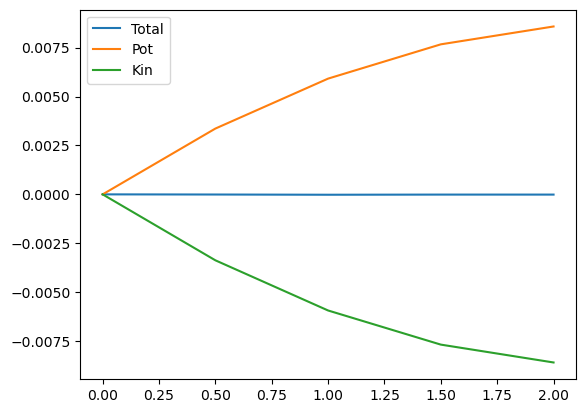

In [10]:
import h5py 
import matplotlib.pyplot as plt
%matplotlib inline

with h5py.File("FSSH2_traj_000/mem_data.hdf", 'r') as f:
    t = f["time/data"][:]
    energy = f["Etot_ave/data"][:] - f["Etot_ave/data"][0]
    epot = f["Epot_ave/data"][:] - f["Epot_ave/data"][0]
    ekin = f["Ekin_ave/data"][:] - f["Ekin_ave/data"][0]    
    
    plt.plot(t * units.au2fs, energy * units.au2ev, label="Total")
    plt.plot(t * units.au2fs, epot * units.au2ev, label="Pot")
    plt.plot(t * units.au2fs, ekin * units.au2ev, label="Kin")
    
    plt.legend()
    plt.show()

/projects/academic/cyberwksp21/SOFTWARE/libra/_build/src/libra_py/dynamics/tsh/plot.py:388: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=legend_fontsize)
/projects/academic/cyberwksp21/SOFTWARE/libra/_build/src/libra_py/dynamics/tsh/plot.py:454: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=legend_fontsize)
/projects/academic/cyberwksp21/SOFTWARE/libra/_build/src/libra_py/dynamics/tsh/plot.py:520: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=legend_fontsize)
/projects/academic/cyberwksp21/SOFTWARE/libra/_build/src/libra_py/dynamics/tsh/plot.py:583: UserW

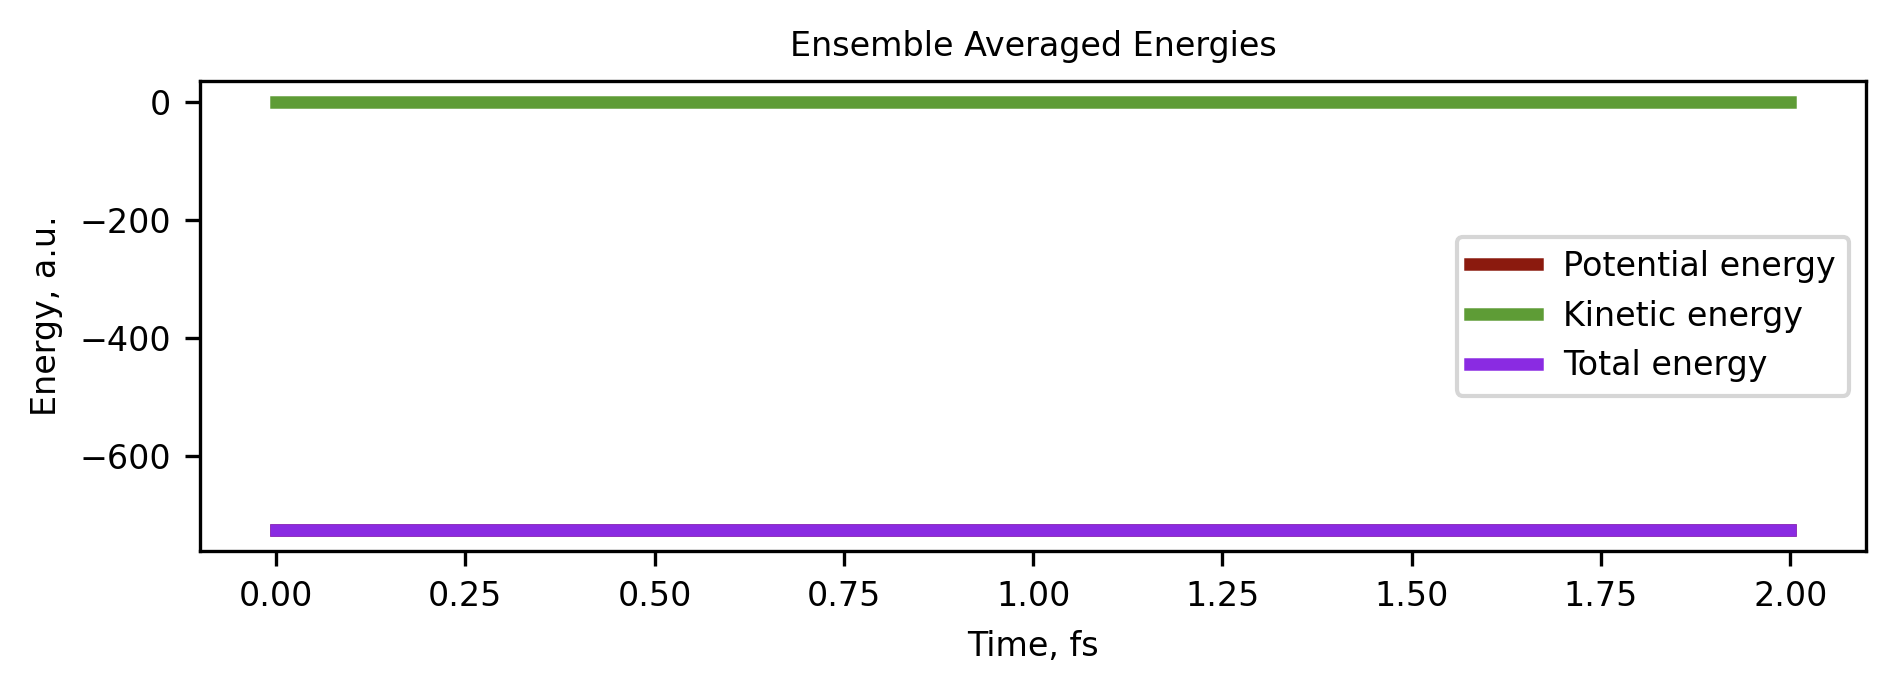

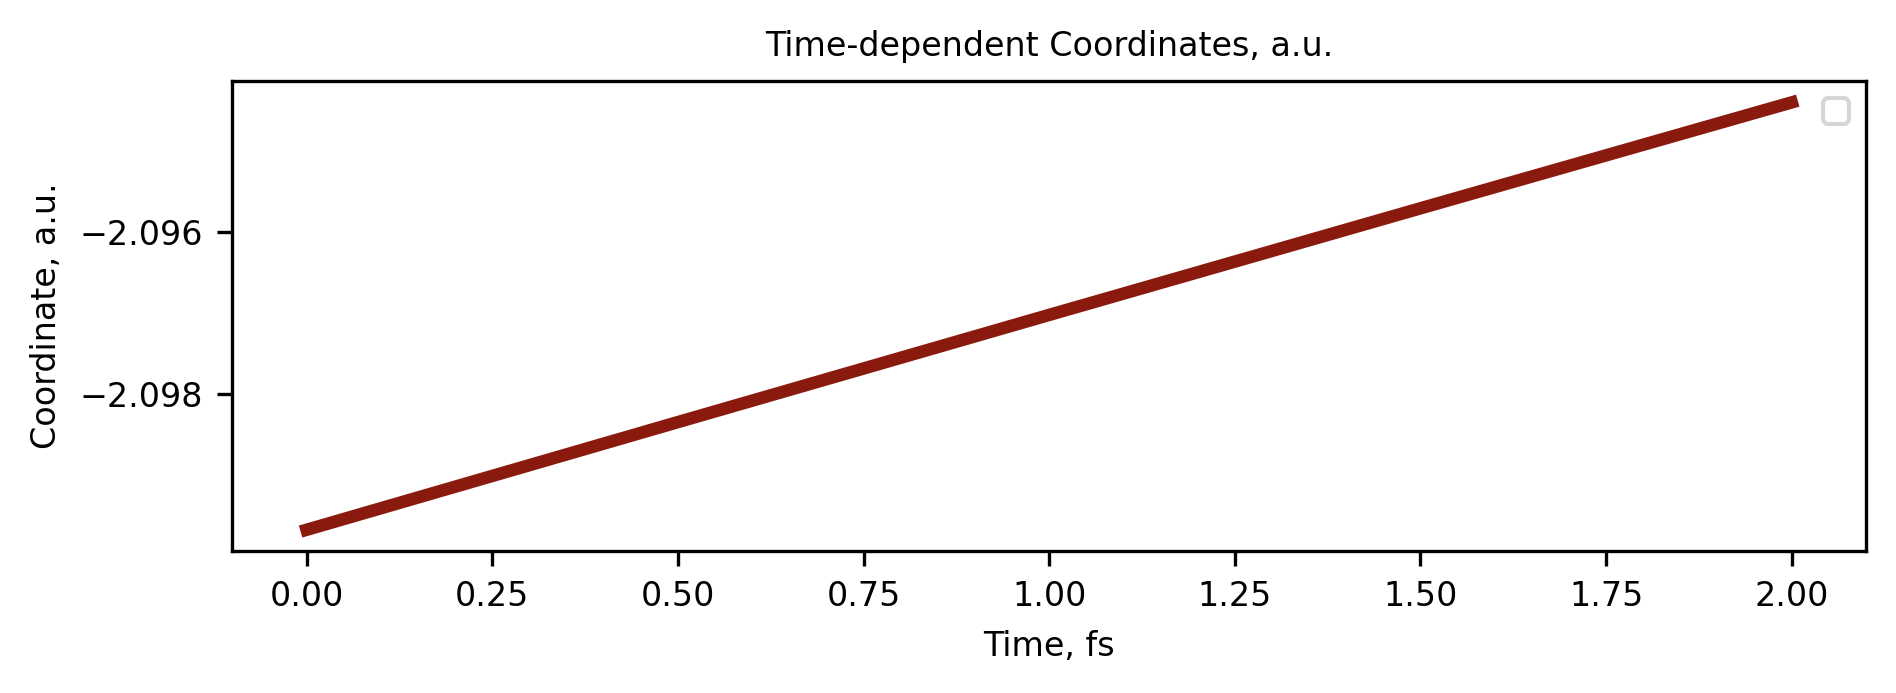

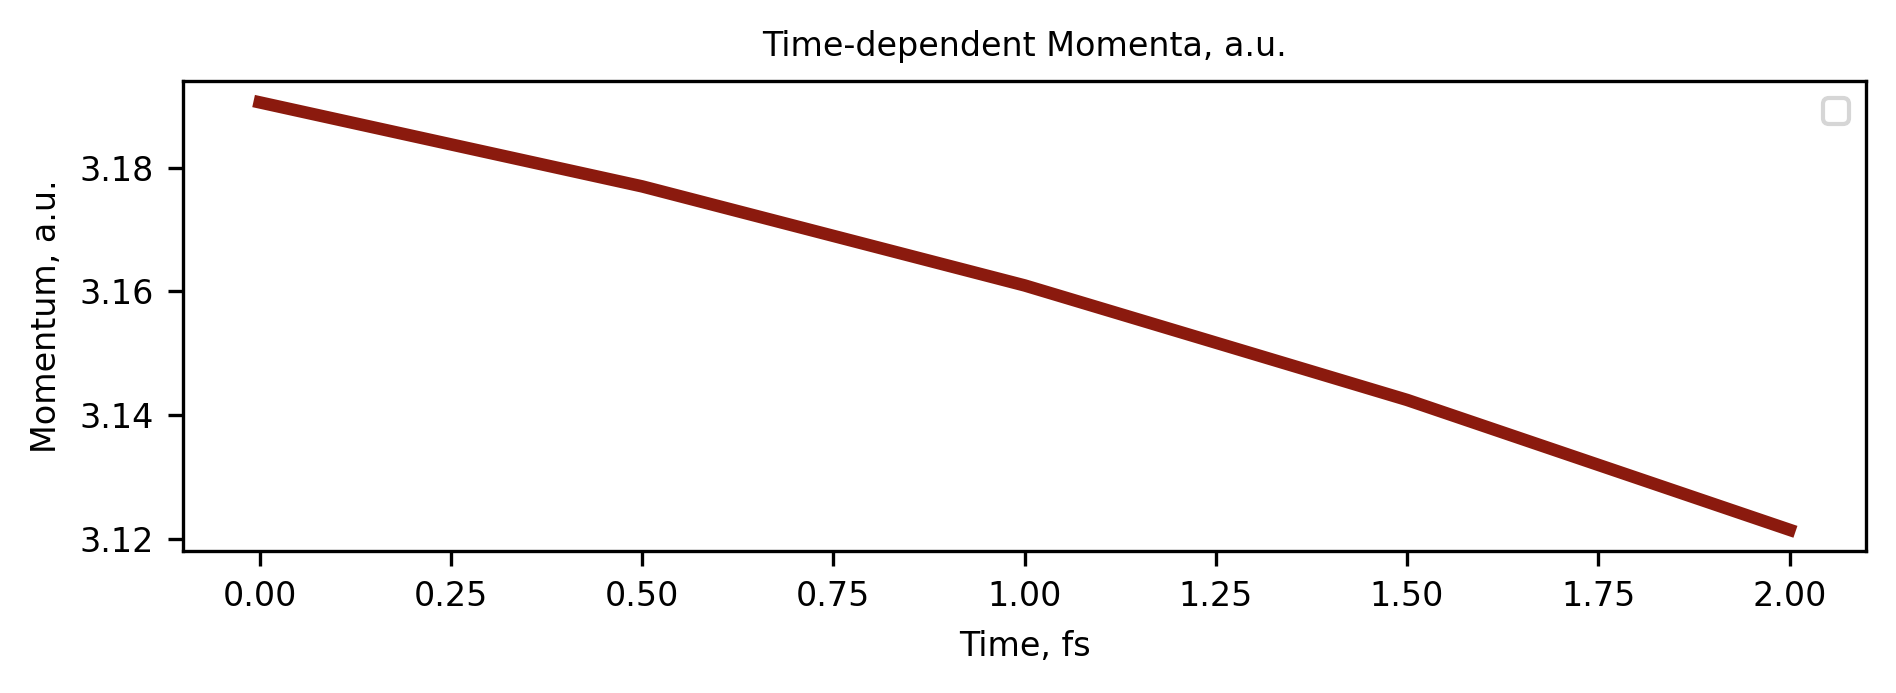

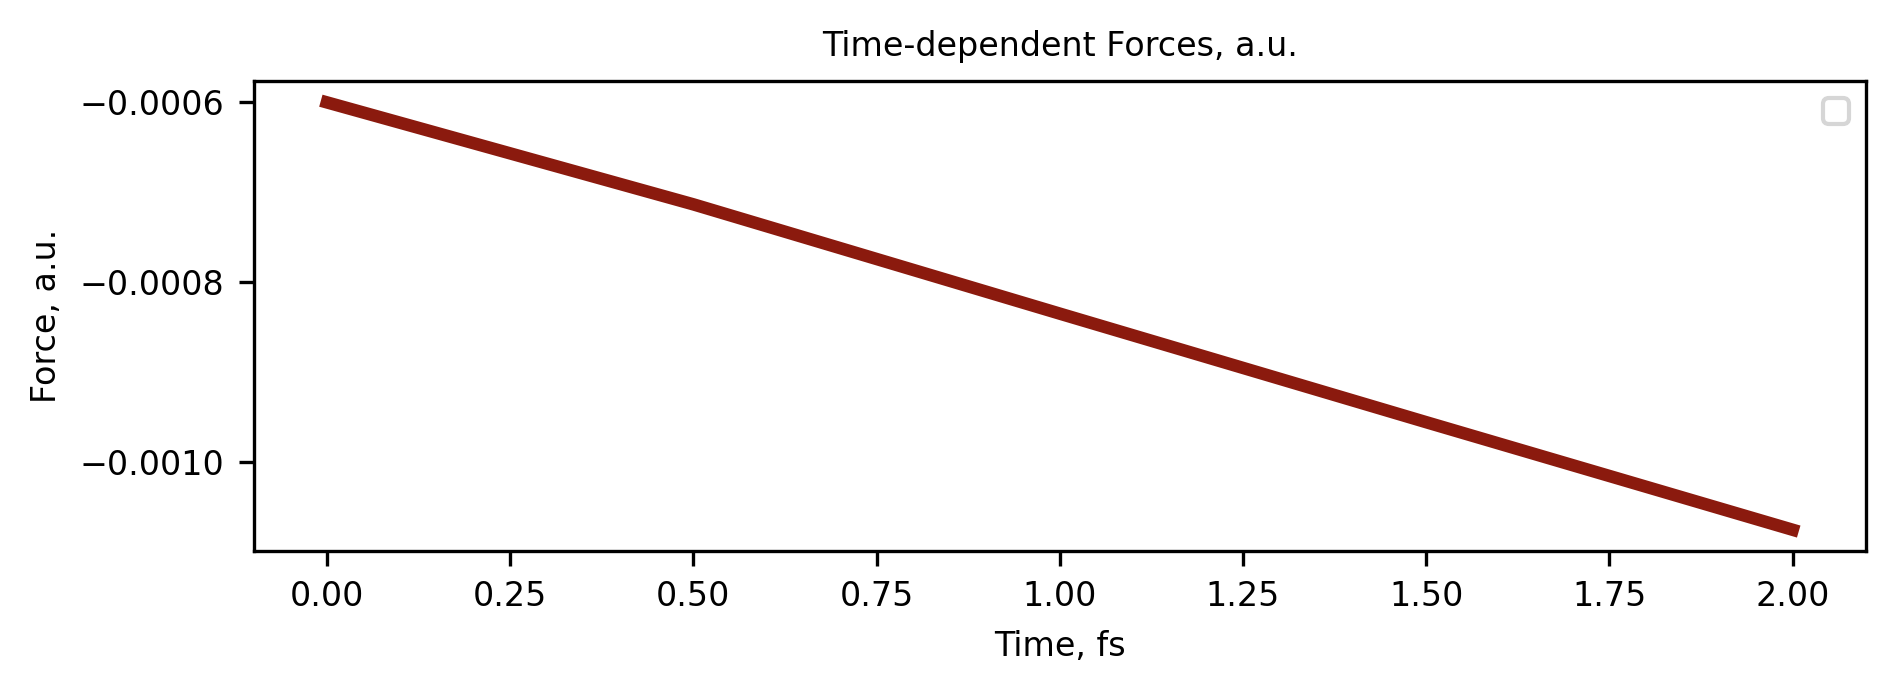

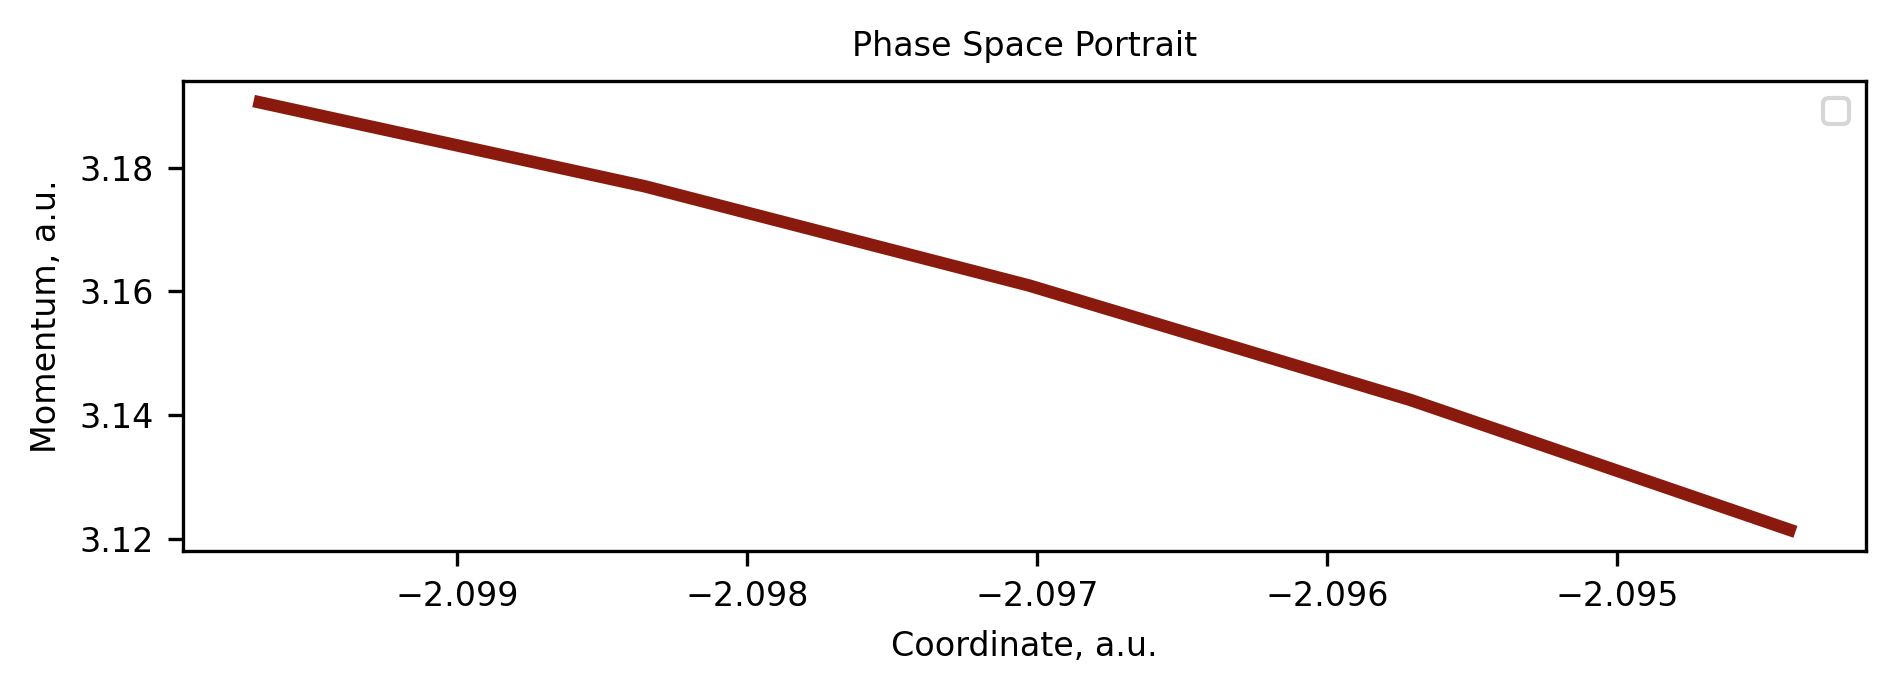

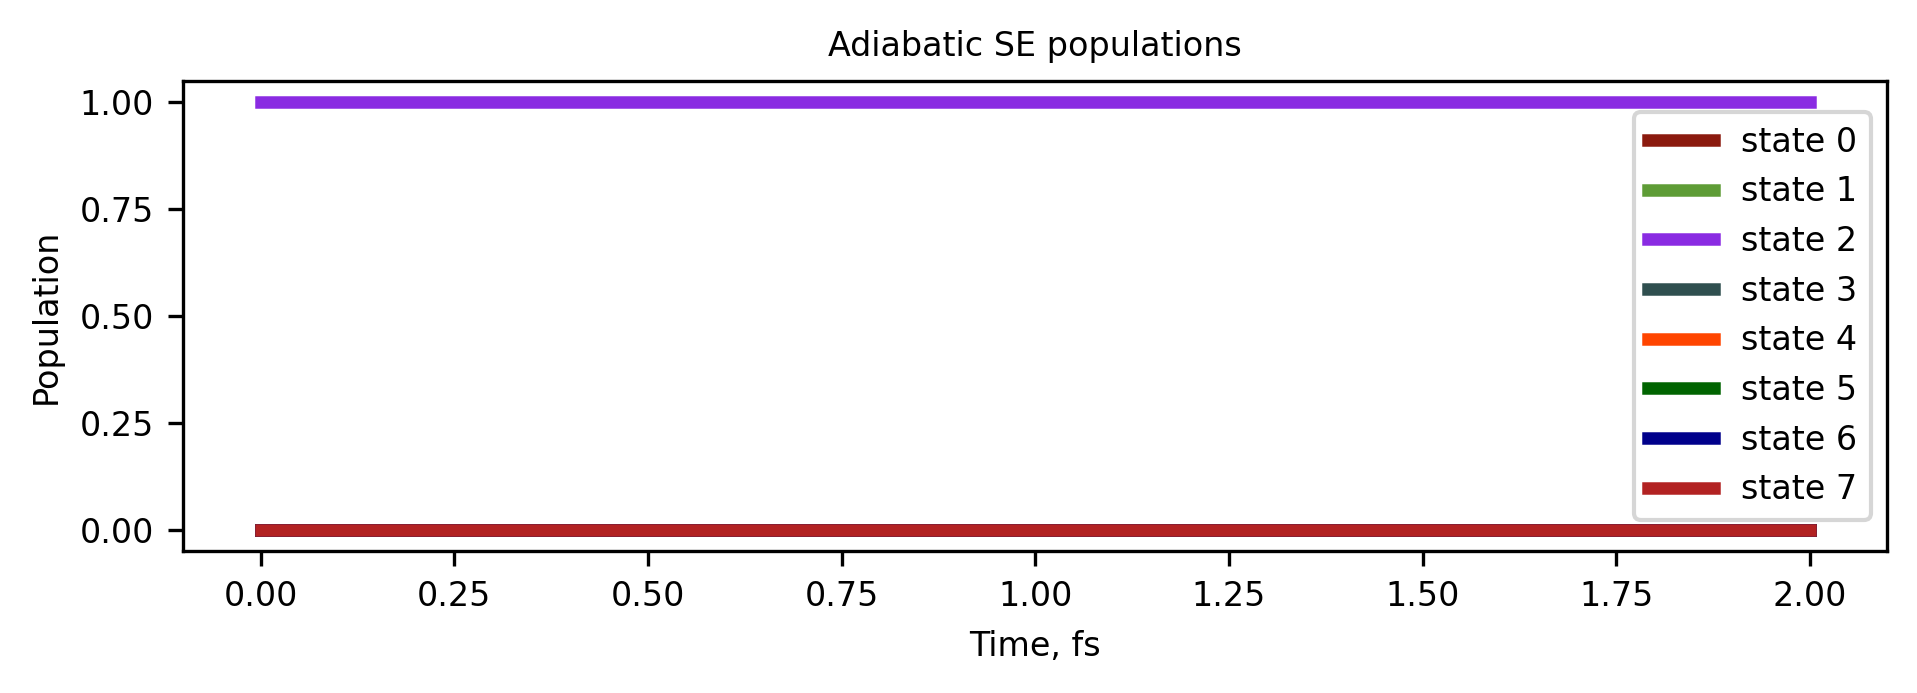

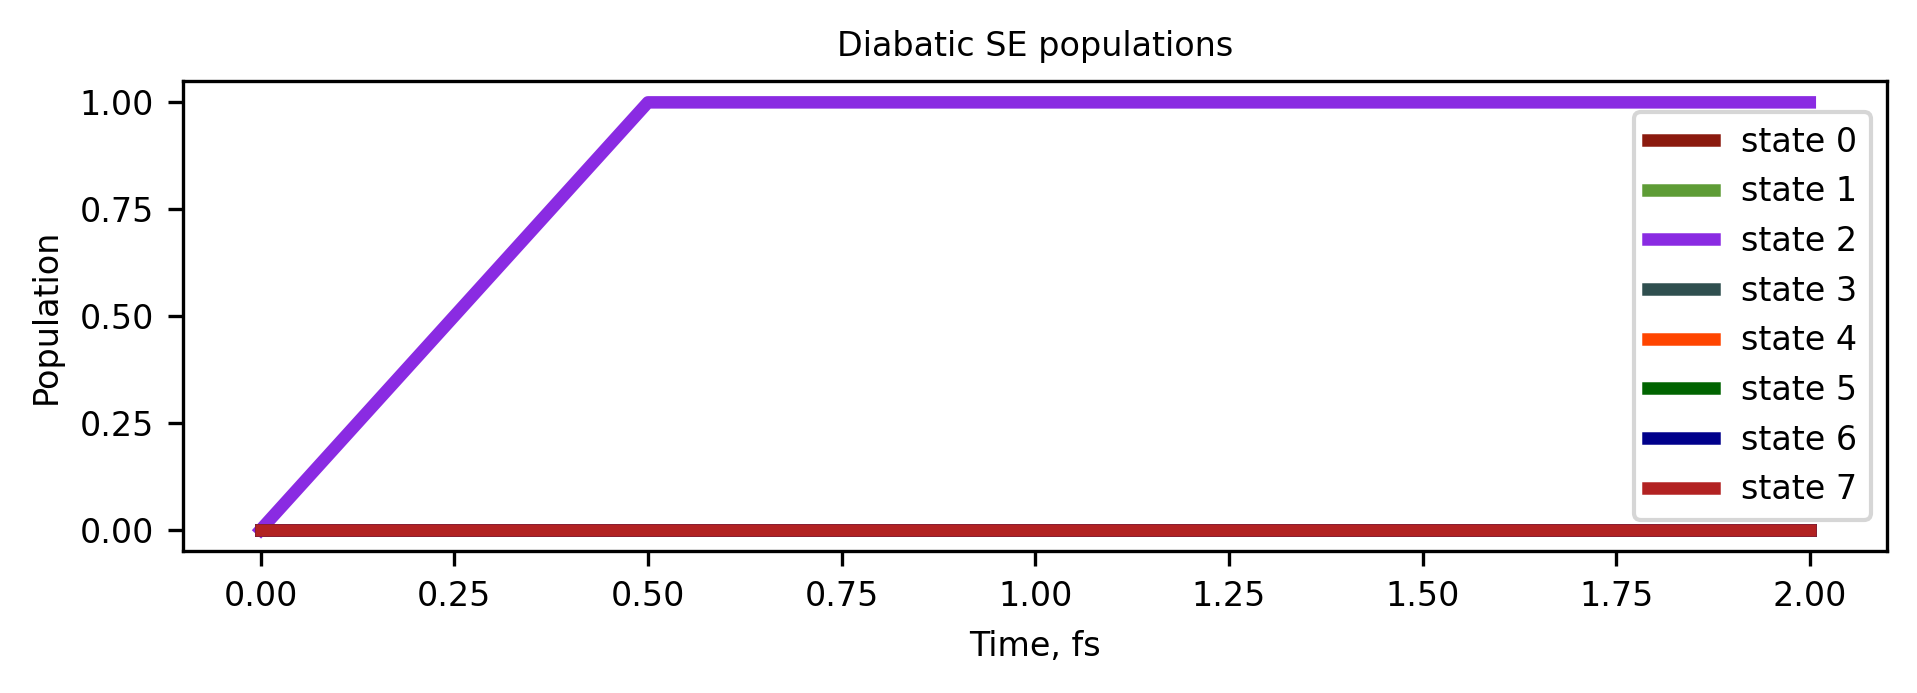

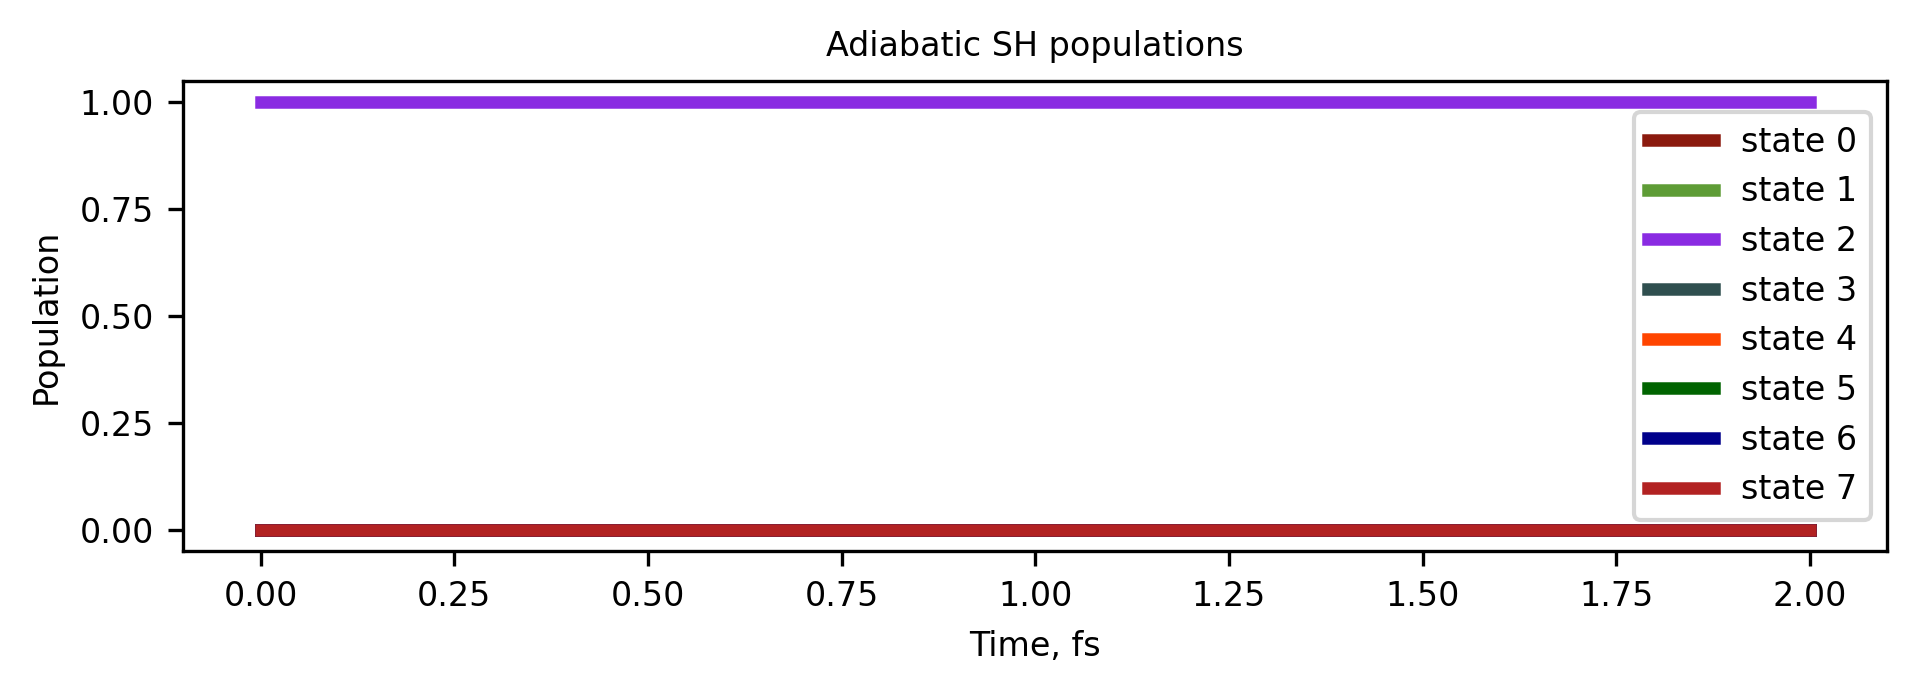

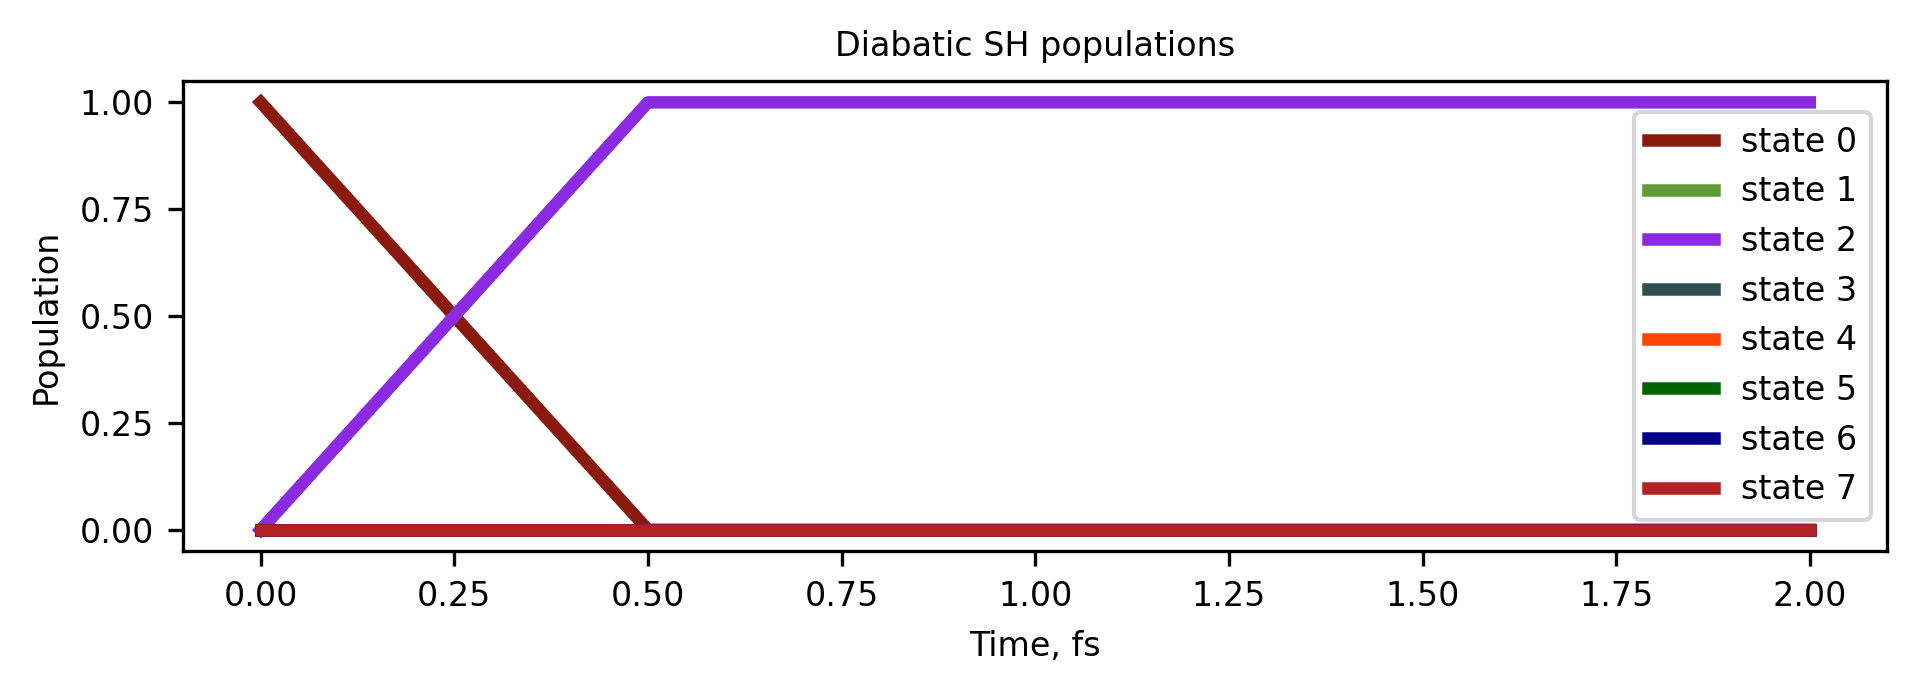

In [11]:
############################################################
### 5. Plot the results - preliminary plotting
############################################################
pref = "FSSH2_traj_000"
NSTATES = nstates

NTRAJ = dyn_general["ntraj"]
plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":3,
                "which_trajectories":list(range(NTRAJ)), "which_dofs":[0], "which_adi_states":list(range(NSTATES)), 
                "which_dia_states":list(range(NSTATES)), 
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8, "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":["coordinates", "momenta",  "forces", "energies", "phase_space", "se_pop_adi",
                                "se_pop_dia", "sh_pop_adi", "sh_pop_dia" ], 
                "which_energies":["potential", "kinetic", "total"],
                "save_figures":1, "do_show":1, "no_label":1
              }
tsh_dynamics_plot.plot_dynamics(plot_params)

### 1.8. Make trajectories for VMD visualization of dynamics
<a name="1.8"></a>[Back to TOC](#toc)

In [12]:
# For Al3
labels = ['Al', 'Al', 'Al']



F = h5py.File('FSSH2_traj_000/mem_data.hdf')
q = np.array(F['q/data'])
F.close()


nsteps, ntraj, ndof = q.shape
nat = ndof // 3
os.system("mkdir trajectories")

for i in range(ntraj):
    #os.system(F"mkdir trajectories/traj_{i}.xyz")
    f = open(F"trajectories/traj_{i}.xyz", "w")
    for istep in range(nsteps):
        f.write(F"{nat}\n\n")
        for iat in range(nat):
            L = labels[iat]
            x = q[istep, i, 3*iat + 0] / units.Angst
            y = q[istep, i, 3*iat + 1] / units.Angst
            z = q[istep, i, 3*iat + 2] / units.Angst
            f.write(F"{L} {x}  {y}  {z}\n")
    f.close()

mkdir: cannot create directory ‘trajectories’: File exists
